# Лабораторная работа №2 «Обнаружение аномалий и выбросов в данных»

**Цель работы:**
1. Освоить методы обнаружения выбросов на основе статистических критериев.
2. Научиться проверять гипотезу о нормальности распределения.
3. Реализовать методы Z-оценки и межквартильного расстояния (IQR).
4. Применить модельные и метрические методы обнаружения аномалий.
5. Сформировать обоснованные решения по обработке выбросов с учетом предметной области.

## Задание 1. Загрузка и профилирование данных

Загрузим датасет, выведем общую информацию и опишем диапазоны значений и пропуски.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета
df = pd.read_csv('../data/Energy Production Dataset.csv')

# Информация о типах данных и пропусках
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB


In [2]:
# Описательные статистики
df.describe()

,Start_Hour,End_Hour,Day_of_Year,Production
count,51864.000000,51864.000000,51864.000000,51864.000000
mean,11.500000,11.500000,180.798415,6215.069933
std,6.922253,6.922253,104.291387,3978.364965
min,0.000000,0.000000,1.000000,58.000000
25%,5.750000,5.750000,91.000000,3111.000000
50%,11.500000,11.500000,181.000000,5372.000000
75%,17.250000,17.250000,271.000000,8501.000000
max,23.000000,23.000000,366.000000,23446.000000


**Анализ:**
* **Пропуски:** Исходя из вывода `df.info()`, датасет состоит из 51864 строк без пропущенных значений (Non-Null Count совпадает с общим количеством строк).
* **Диапазоны значений:** 
  * `Production` (Производство энергии) варьируется от 58 до 23446 МВт*ч.
  * `Start_Hour` и `End_Hour` лежат в корректном диапазоне от 0 до 23.
  * `Day_of_Year` варьируется от 1 до 366.
* **Подозрительные экстремальные значения:** Максимальное значение признака `Production` (23446) значительно удалено от 75-го перцентиля (8501), что может свидетельствовать о наличии выбросов (возможно, пиковые мощности или ошибки учета).

Для дальнейшего визуального анализа выберем два числовых признака: `Production` и `Day_of_Year`.

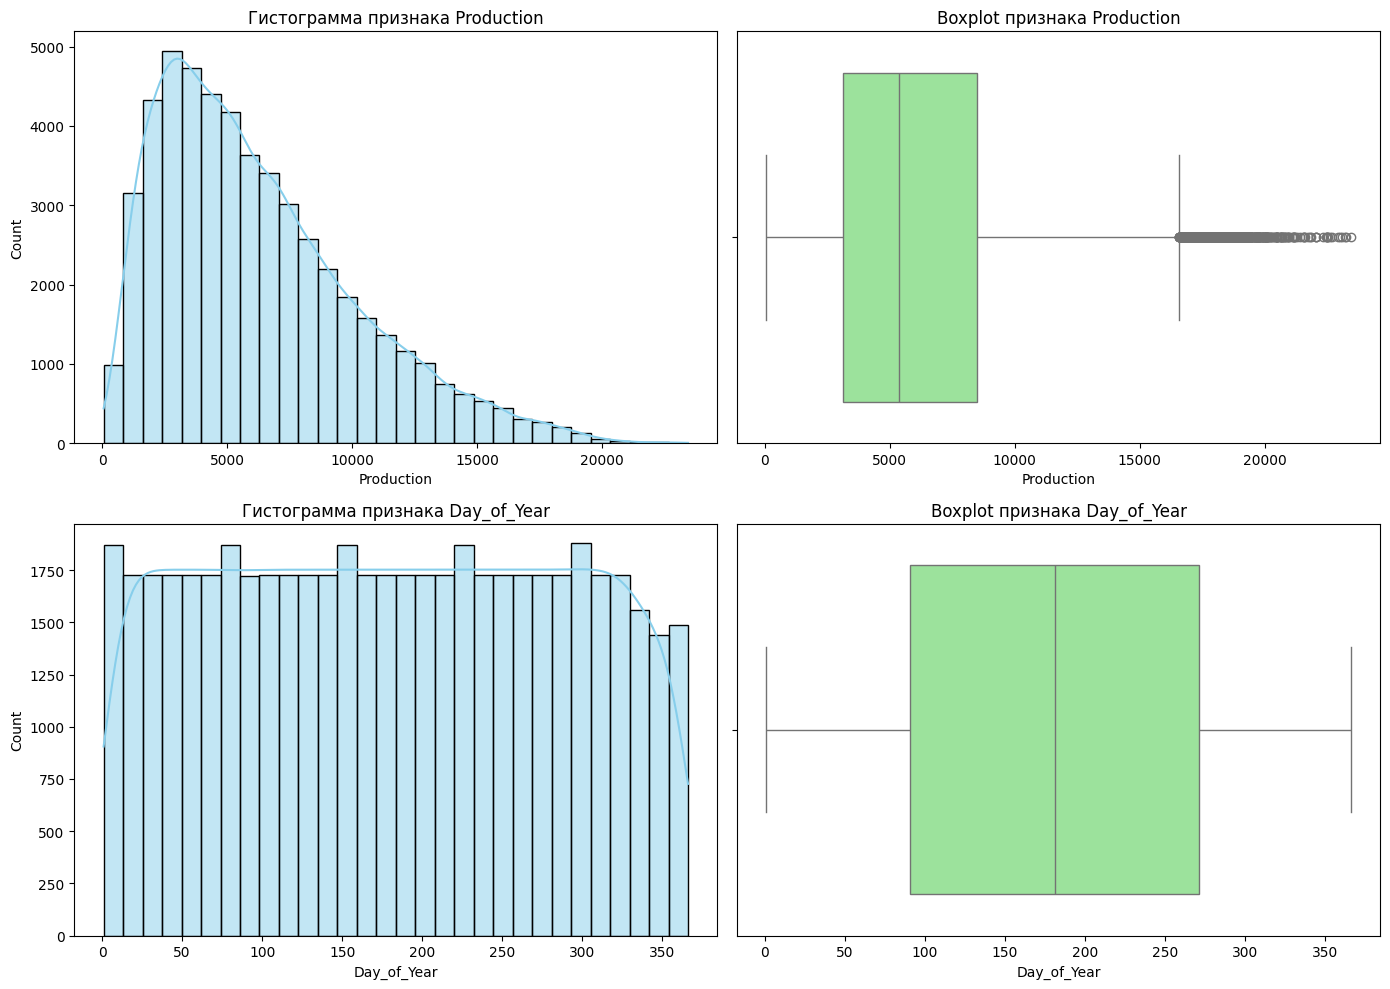

In [3]:
# Визуальный анализ двух числовых признаков
features_to_plot = ['Production', 'Day_of_Year']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(features_to_plot):
    # Гистограмма
    sns.histplot(df[col], kde=True, ax=axes[i, 0], bins=30, color='skyblue')
    axes[i, 0].set_title(f'Гистограмма признака {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot признака {col}')

plt.tight_layout()
plt.show()

**Вывод по визуальному анализу:**
* **Production:** Распределение имеет сильную правостороннюю асимметрию. Boxplot явно показывает множество точек, лежащих далеко за правым усом. Это свидетельствует о наличии выбросов с аномально высокими значениями выработки энергии.
* **Day_of_Year:** Распределение близко к равномерному (что логично для дней в году), выбросов на boxplot не наблюдается.

## Задание 2. Проверка нормальности распределения
Проведем проверку для признака `Production`.

In [4]:
col = 'Production'
data_prod = df[col].dropna()

# 1. Описательные характеристики
mean_val = data_prod.mean()
median_val = data_prod.median()
std_val = data_prod.std()
skewness = stats.skew(data_prod)
kurtosis = stats.kurtosis(data_prod)

print(f"Описательные характеристики для '{col}':")
print(f"Среднее: {mean_val:.2f}")
print(f"Медиана: {median_val:.2f}")
print(f"Стандартное отклонение: {std_val:.2f}")
print(f"Коэффициент асимметрии: {skewness:.2f}")
print(f"Коэффициент эксцесса: {kurtosis:.2f}")

Описательные характеристики для 'Production':
Среднее: 6215.07
Медиана: 5372.00
Стандартное отклонение: 3978.36
Коэффициент асимметрии: 0.93
Коэффициент эксцесса: 0.47


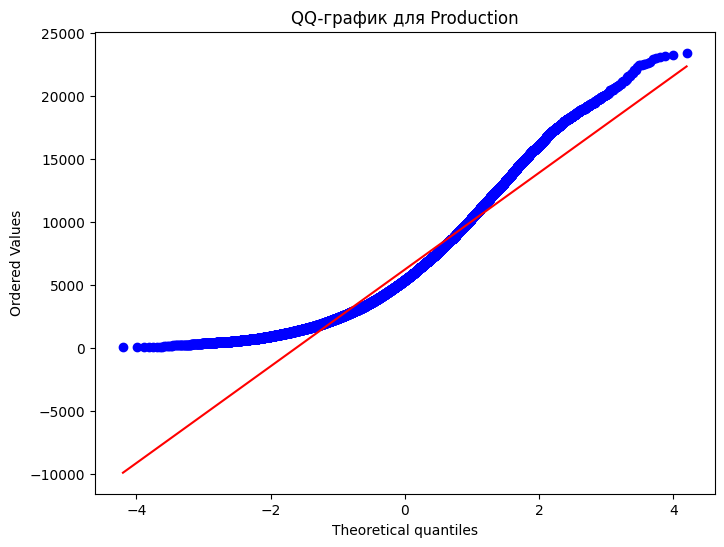

In [5]:
# 2. Графический анализ (QQ-график)
plt.figure(figsize=(8, 6))
stats.probplot(data_prod, dist="norm", plot=plt)
plt.title(f'QQ-график для {col}')
plt.show()

**Сравнение формы распределения с нормальным:**
Точки на QQ-графике существенно отклоняются от диагональной прямой (особенно на концах, образуя характерную дугу), что указывает на то, что распределение не является нормальным. Сильная правосторонняя асимметрия, выявленная ранее, подтверждается.

In [6]:
# 3. Критерий Шапиро-Уилка
# В связи с ограничением метода Шапиро-Уилка для N > 5000, применим тест на случайной подвыборке
sample_prod = data_prod.sample(n=5000, random_state=42)
stat, p_value = stats.shapiro(sample_prod)

print(f"Статистика Шапиро-Уилка: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

Статистика Шапиро-Уилка: 0.9333
p-value: 1.1926e-42


**Формулировка гипотез:**
* **H0**: Выборка подчиняется нормальному распределению.
* **H1**: Выборка не подчиняется нормальному распределению.
Уровень значимости: $\alpha=0.05$

**Вывод:** 
Поскольку `p-value` значительно меньше уровня значимости $\alpha$ (0.05), мы отклоняем нулевую гипотезу (H0). Распределение признака `Production` статистически значимо отличается от нормального.

## Задание 3. Обнаружение выбросов статистическими методами
Для сравнения используем признак `Production`.

Количество выбросов (Метод Z-score, |Z| > 3): 402


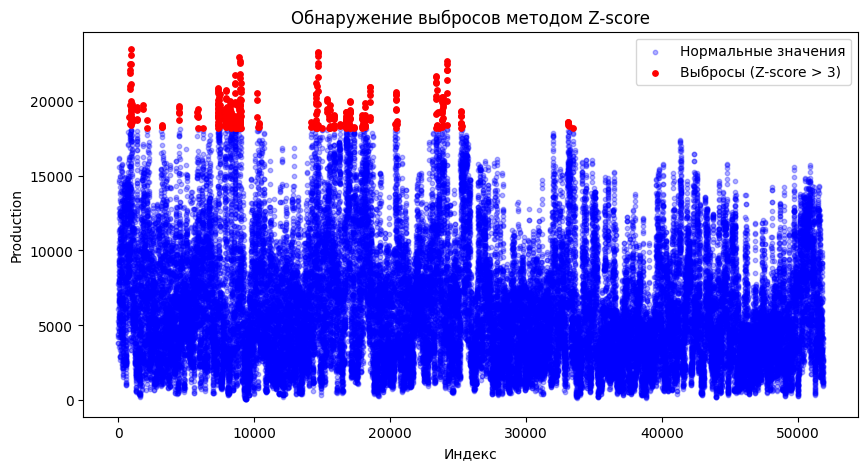

In [7]:
# 1. Метод Z-score
z_scores = stats.zscore(data_prod)
abs_z_scores = np.abs(z_scores)
outliers_z = data_prod[abs_z_scores > 3]

print(f"Количество выбросов (Метод Z-score, |Z| > 3): {len(outliers_z)}")

# Визуализация выбросов Z-score
plt.figure(figsize=(10, 5))
plt.scatter(data_prod.index, data_prod.values, color='blue', alpha=0.3, label='Нормальные значения', s=10)
plt.scatter(outliers_z.index, outliers_z.values, color='red', label='Выбросы (Z-score > 3)', s=15)
plt.title('Обнаружение выбросов методом Z-score')
plt.xlabel('Индекс')
plt.ylabel('Production')
plt.legend()
plt.show()

Границы IQR: [-4974.00, 16586.00]
Количество выбросов (Метод IQR): 951


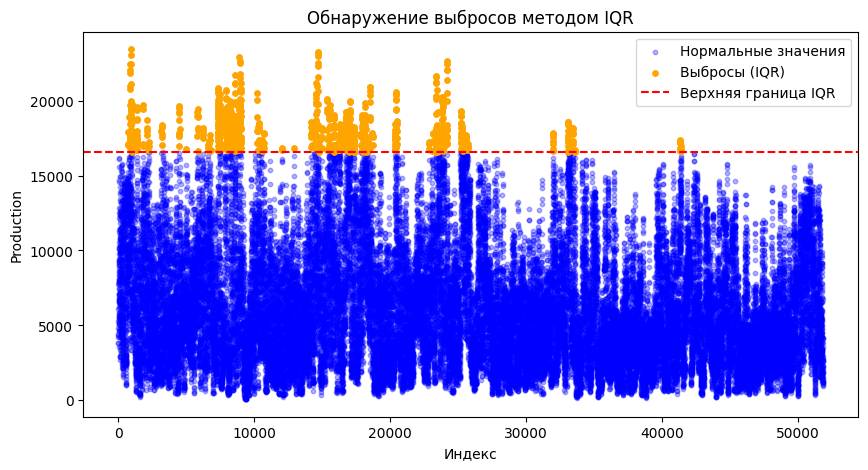

In [8]:
# 2. Метод IQR
Q1 = data_prod.quantile(0.25)
Q3 = data_prod.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = data_prod[(data_prod < lower_bound) | (data_prod > upper_bound)]

print(f"Границы IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Количество выбросов (Метод IQR): {len(outliers_iqr)}")

# Визуализация выбросов IQR
plt.figure(figsize=(10, 5))
plt.scatter(data_prod.index, data_prod.values, color='blue', alpha=0.3, label='Нормальные значения', s=10)
plt.scatter(outliers_iqr.index, outliers_iqr.values, color='orange', label='Выбросы (IQR)', s=15)
plt.axhline(upper_bound, color='red', linestyle='--', label='Верхняя граница IQR')
plt.title('Обнаружение выбросов методом IQR')
plt.xlabel('Индекс')
plt.ylabel('Production')
plt.legend()
plt.show()

**Сравнительный анализ методов (Z-score vs IQR):**
* Метод **Z-score** предполагает, что данные распределены нормально. Поскольку распределение `Production` сильно скошено вправо (асимметрично), среднее значение и стандартное отклонение смещаются в сторону высоких значений. Как следствие, Z-score находит меньше выбросов.
* Метод **IQR** является более робастным (устойчивым) к выбросам и асимметрии, так как опирается на медиану и квартили. Он определил больше потенциальных аномалий (верхняя граница оказалась ниже, чем порог $|Z| > 3$). Для асимметричных распределений, подобных этому, IQR обычно работает корректнее.

## Задание 4. Метод локальной плотности
В качестве метрик расстояния используем Евклидово (default) и масштабирование с помощью StandardScaler.
Анализируем двумерное пространство: `Day_of_Year` и `Production`.

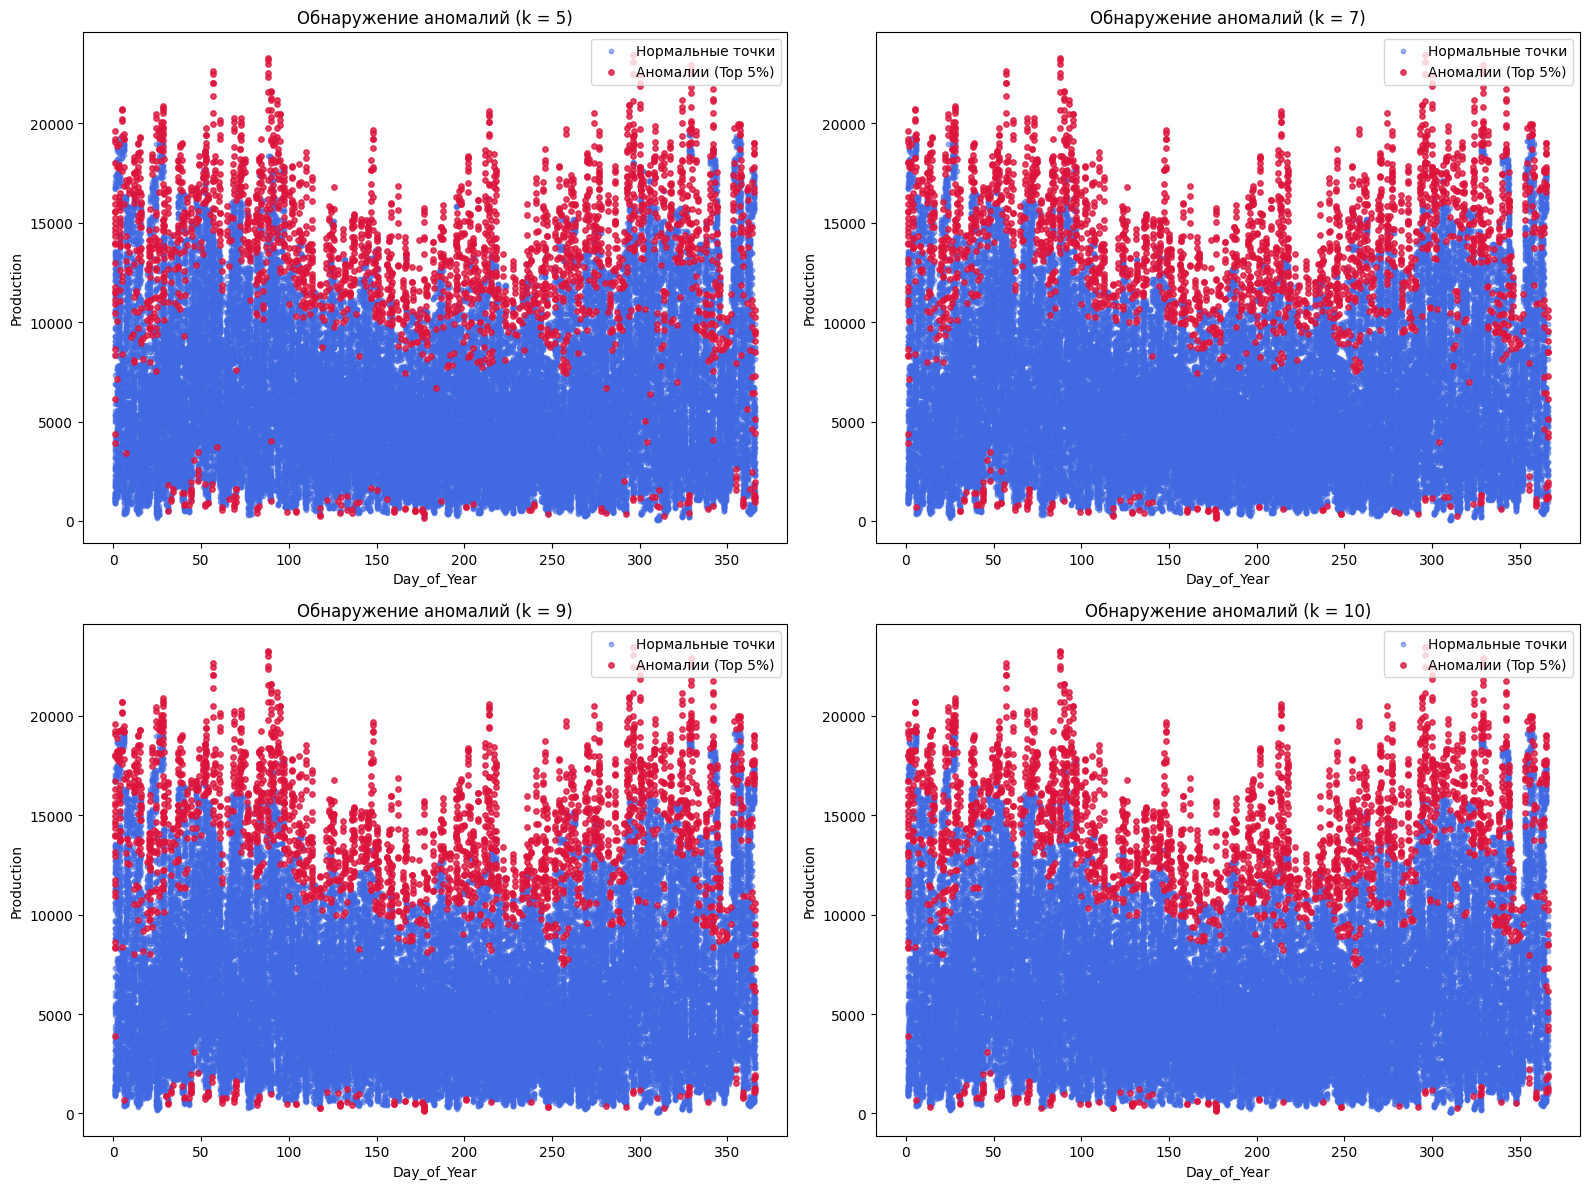

In [9]:
# Подготовка данных: выбираем признаки и масштабируем их
features = ['Day_of_Year', 'Production']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = [5, 7, 9, 10]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    # Инициализация модели NearestNeighbors (ищем k+1 соседей, т.к. первая точка - это она сама)
    nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    nbrs.fit(X_scaled)
    
    # Вычисление расстояний
    distances, indices = nbrs.kneighbors(X_scaled)
    
    # Среднее расстояние до k соседей (исключаем нулевой столбец, так как дистанция до самой себя = 0)
    avg_dist_to_k = distances[:, 1:].mean(axis=1)
    
    # Определяем порог для верхних 5%
    threshold_95 = np.percentile(avg_dist_to_k, 95)
    anomalies = avg_dist_to_k > threshold_95
    
    # Визуализация (scatter plot)
    ax = axes[idx]
    ax.scatter(X['Day_of_Year'][~anomalies], X['Production'][~anomalies], 
               c='royalblue', label='Нормальные точки', alpha=0.5, s=10)
    ax.scatter(X['Day_of_Year'][anomalies], X['Production'][anomalies], 
               c='crimson', label='Аномалии (Top 5%)', alpha=0.8, s=15)
    
    ax.set_title(f'Обнаружение аномалий (k = {k})')
    ax.set_xlabel('Day_of_Year')
    ax.set_ylabel('Production')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Анализ устойчивости метода при изменении $k$:**
* На графиках видно, что точки, помеченные как аномальные (красные), в основном сосредоточены в областях высокой выработки (`Production` > 15000) и располагаются разреженно, независимо от дня в году.
* При варьировании $k$ от 5 до 10 результаты остаются визуально устойчивыми: одни и те же изолированные группы точек определяются как аномалии.
* Большее значение $k$ делает метрику чуть более сглаженной (устойчивой к случайным выбросам внутри плотных кластеров), но в нашем наборе данных с учетом выбранного отсечения (top 5%) влияние параметра $k$ минимально, алгоритм стабильно выявляет точки в зонах с низкой плотностью распределения.